# Sparsity Analysis

Analyze the sparsity (ratio of active/non-zero data points) across all three aggregation levels to understand the distribution of gaps in the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import load_dataset, ratio_active
from scipy.stats import gaussian_kde

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

## Load Data

In [2]:
d_inst = load_dataset("institutions")
df_inst = d_inst["df"]

100%|█| 283/283 [00


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [100   0 232  70 268 ... 218 196 133 172 156], Length=283
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size: 64
 

institutions (AGG_1_HOUR): 283 series loaded


In [3]:
d_sub = load_dataset("subnets")
df_sub = d_sub["df"]

100%|█| 548/548 [00


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [230   9 531  54 189 ... 145 480 118  73 498], Length=548
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch siz

subnets (AGG_1_HOUR): 548 series loaded


In [4]:
d_ips = load_dataset("ips")
df_ips = d_ips["df"]

100%|█| 1000/1000 [


Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_1_HOUR
    Source: SourceType.IP_ADDRESSES_SAMPLE

    Time series
        Time series IDS: [ 367548  635778 1949634  296195  603147 ... 1825722   10809  450529   10125 1702900], Length=1000
    Time periods
        Train time periods: range(0, 6718)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 6718)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        T

ips (AGG_1_HOUR): 1000 series loaded


## Compute Sparsity per Series

In [ ]:
def compute_sparsity(df, id_col, feature="n_bytes"):
    """Compute sparsity metrics for each series."""
    rows = []
    for ts_id, grp in df.groupby(id_col):
        y = grp[feature].astype(float)
        n_total = len(y)
        n_active = (y > 0).sum()
        n_zero = n_total - n_active
        rows.append({
            id_col: ts_id,
            "n_total": n_total,
            "n_active": int(n_active),
            "n_zero": int(n_zero),
            "ratio_active": n_active / n_total if n_total > 0 else 0.0,
            "ratio_zero": n_zero / n_total if n_total > 0 else 0.0,
        })
    return pd.DataFrame(rows)

In [6]:
sp_inst = compute_sparsity(df_inst, "id_institution")
sp_sub = compute_sparsity(df_sub, "id_institution_subnet")
sp_ips = compute_sparsity(df_ips, "id_ip")

## Summary Statistics

In [7]:
for df_sp, label in [(sp_inst, "Institutions"), (sp_sub, "Subnets"), (sp_ips, "IPs")]:
    print(f"\n=== {label} ({len(df_sp)} series) ===")
    print(df_sp["ratio_active"].describe())


=== Institutions (283 series) ===
count    283.000000
mean       0.988948
std        0.073473
min        0.134266
25%        0.999702
50%        0.999851
75%        0.999851
max        0.999851
Name: ratio_active, dtype: float64

=== Subnets (548 series) ===
count    548.000000
mean       0.961024
std        0.143118
min        0.064454
25%        0.999256
50%        0.999851
75%        0.999851
max        0.999851
Name: ratio_active, dtype: float64

=== IPs (1000 series) ===
count    1000.000000
mean        0.209717
std         0.307708
min         0.000298
25%         0.010866
50%         0.074352
75%         0.215466
max         0.999851
Name: ratio_active, dtype: float64


## Distributions

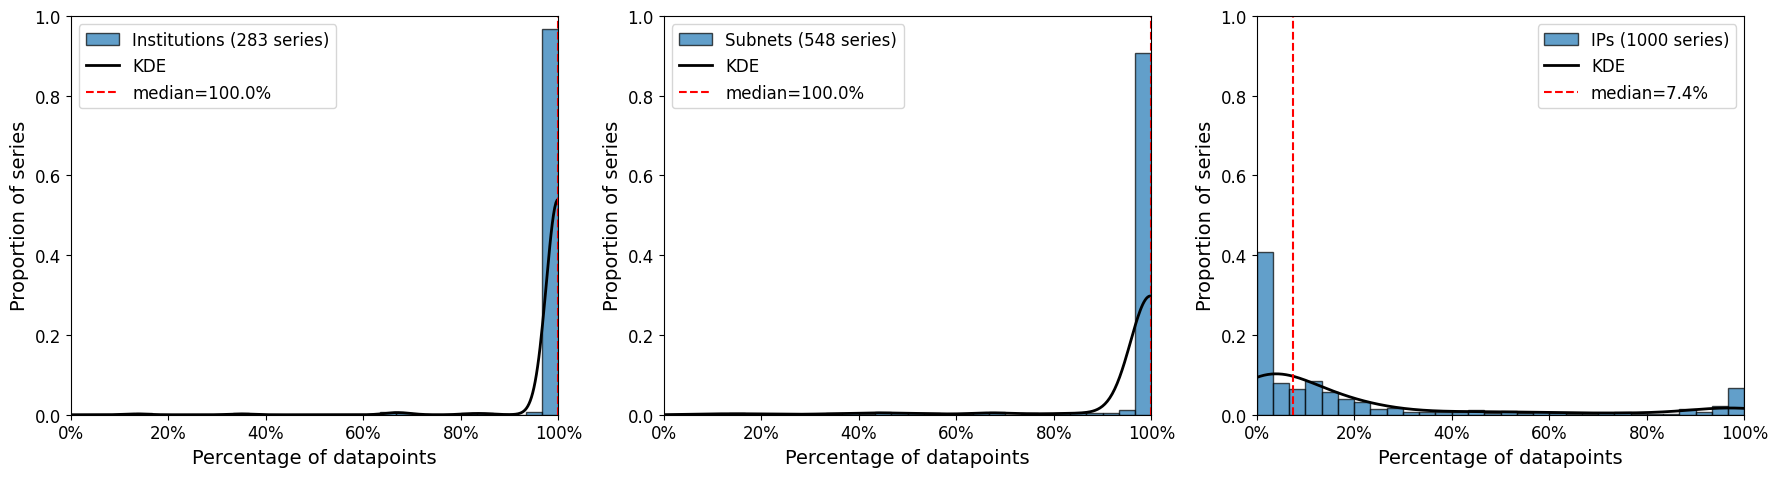

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins = np.linspace(0, 1, 31)
bin_width = bins[1] - bins[0]
xs = np.linspace(0, 1, 400)

for ax, (df_sp, label) in zip(axes, [
    (sp_inst, "Institutions"),
    (sp_sub, "Subnets"),
    (sp_ips, "IPs"),
]):
    y = df_sp["ratio_active"].values
    weights = np.ones_like(y) / len(y)
    ax.hist(y, bins=bins, weights=weights, edgecolor="black", alpha=0.7,
            label=f"{label} ({len(df_sp)} series)")

    kde = gaussian_kde(y)
    ax.plot(xs, kde(xs) * bin_width, color="black", linewidth=2, label="KDE")

    ax.axvline(np.median(y), color="red", linestyle="--",
               label=f"median={np.median(y)*100:.1f}%")
    ax.set_xlabel("Percentage of datapoints")
    ax.set_ylabel("Proportion of series")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/xw/ns2nqjw146sg3jt0ghqnyqpw0000gn/T/ipykernel_82143/4184207298.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)


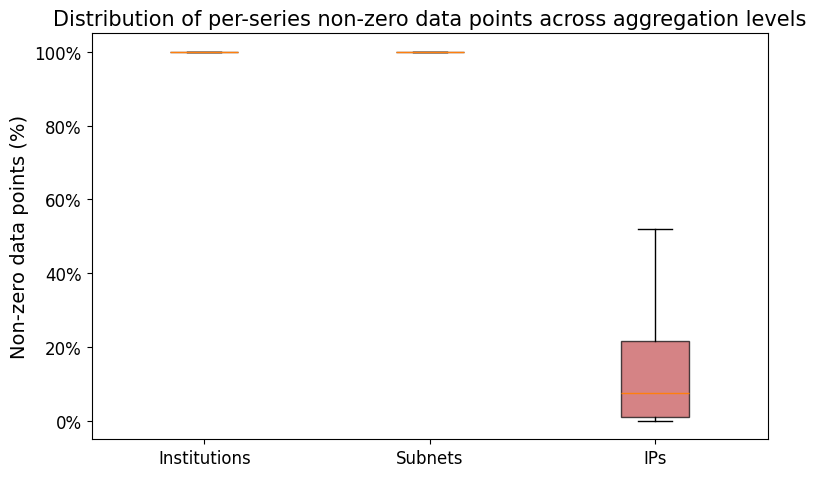

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [sp_inst["ratio_active"] * 100, sp_sub["ratio_active"] * 100, sp_ips["ratio_active"] * 100]
labels = ["Institutions", "Subnets", "IPs"]

bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
colors = ["#4C72B0", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Non-zero data points (%)")
ax.set_title("Distribution of per-series non-zero data points across aggregation levels")
ax.set_ylim(-5, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.tight_layout()
plt.show()

## Sparsity Buckets

How many series fall into each sparsity category?

In [10]:
bins = [0, 0.05, 0.15, 0.30, 0.50, 0.70, 0.85, 0.95, 0.99, 1.001]
labels = ["<5%", "5-15%", "15-30%", "30-50%", "50-70%", "70-85%", "85-95%", "95-99%", ">99%"]

for df_sp, name in [(sp_inst, "Institutions"), (sp_sub, "Subnets"), (sp_ips, "IPs")]:
    df_sp["bucket"] = pd.cut(df_sp["ratio_active"], bins=bins, labels=labels, right=False)
    counts = df_sp["bucket"].value_counts().sort_index()
    print(f"\n=== {name} ===")
    for bucket, count in counts.items():
        pct = count / len(df_sp) * 100
        print(f"  {bucket:>8s}: {count:4d} ({pct:5.1f}%)")


=== Institutions ===
       <5%:    0 (  0.0%)
     5-15%:    1 (  0.4%)
    15-30%:    0 (  0.0%)
    30-50%:    1 (  0.4%)
    50-70%:    3 (  1.1%)
    70-85%:    1 (  0.4%)
    85-95%:    1 (  0.4%)
    95-99%:    7 (  2.5%)
      >99%:  269 ( 95.1%)

=== Subnets ===
       <5%:    0 (  0.0%)
     5-15%:    4 (  0.7%)
    15-30%:    4 (  0.7%)
    30-50%:   12 (  2.2%)
    50-70%:   12 (  2.2%)
    70-85%:    5 (  0.9%)
    85-95%:   11 (  2.0%)
    95-99%:   28 (  5.1%)
      >99%:  472 ( 86.1%)

=== IPs ===
       <5%:  449 ( 44.9%)
     5-15%:  223 ( 22.3%)
    15-30%:  125 ( 12.5%)
    30-50%:   44 (  4.4%)
    50-70%:   32 (  3.2%)
    70-85%:   18 (  1.8%)
    85-95%:   31 (  3.1%)
    95-99%:   31 (  3.1%)
      >99%:   47 (  4.7%)


## Most Sparse and Most Dense Series

In [11]:
for df_sp, label, id_col in [
    (sp_inst, "Institutions", "id_institution"),
    (sp_sub, "Subnets", "id_institution_subnet"),
    (sp_ips, "IPs", "id_ip"),
]:
    print(f"\n=== {label} — Most Sparse (lowest activity) ===")
    display(df_sp.sort_values("ratio_active").head(10)[[id_col, "ratio_active", "n_active", "n_zero"]])
    
    print(f"\n=== {label} — Most Dense (highest activity) ===")
    display(df_sp.sort_values("ratio_active", ascending=False).head(10)[[id_col, "ratio_active", "n_active", "n_zero"]])


=== Institutions — Most Sparse (lowest activity) ===


,id_institution,ratio_active,n_active,n_zero
280,282.0,0.134266,902,5816
281,283.0,0.349955,2351,4367
262,264.0,0.661209,4442,2276
275,277.0,0.666419,4477,2241
139,140.0,0.685174,4603,2115
276,278.0,0.820036,5509,1209
258,260.0,0.851146,5718,1000
265,267.0,0.962191,6464,254
270,272.0,0.962489,6466,252
241,243.0,0.972611,6534,184



=== Institutions — Most Dense (highest activity) ===


,id_institution,ratio_active,n_active,n_zero
0,0.0,0.999851,6717,1
154,155.0,0.999851,6717,1
156,157.0,0.999851,6717,1
158,159.0,0.999851,6717,1
159,160.0,0.999851,6717,1
160,161.0,0.999851,6717,1
161,162.0,0.999851,6717,1
162,163.0,0.999851,6717,1
163,164.0,0.999851,6717,1
165,166.0,0.999851,6717,1



=== Subnets — Most Sparse (lowest activity) ===


...

,id_institution_subnet,ratio_active,n_active,n_zero
0,0.0,0.999851,6717,1
301,301.0,0.999851,6717,1
332,332.0,0.999851,6717,1
331,331.0,0.999851,6717,1
330,330.0,0.999851,6717,1
325,325.0,0.999851,6717,1
324,324.0,0.999851,6717,1
323,323.0,0.999851,6717,1
322,322.0,0.999851,6717,1
321,321.0,0.999851,6717,1



=== IPs — Most Sparse (lowest activity) ===


,id_ip,ratio_active,n_active,n_zero
736,1610935.0,0.000298,2,6716
747,1625739.0,0.000298,2,6716
723,1602087.0,0.000298,2,6716
430,524623.0,0.000298,2,6716
722,1599657.0,0.000447,3,6715
657,1517683.0,0.000447,3,6715
678,1550502.0,0.000447,3,6715
488,619502.0,0.000447,3,6715
675,1545824.0,0.000447,3,6715
104,61938.0,0.000595,4,6714



=== IPs — Most Dense (highest activity) ===


,id_ip,ratio_active,n_active,n_zero
0,11.0,0.999851,6717,1
174,156573.0,0.999851,6717,1
245,259860.0,0.999851,6717,1
23,1605.0,0.999851,6717,1
22,1580.0,0.999851,6717,1
20,1553.0,0.999851,6717,1
42,10197.0,0.999851,6717,1
92,44922.0,0.999851,6717,1
17,1370.0,0.999851,6717,1
16,1368.0,0.999851,6717,1


---

# 10-Minute Resolution

Repeat the same sparsity analysis for the `AGG_10_MINUTES` aggregation.

## Load Data (10 min)

In [12]:
from cesnet_tszoo.utils.enums import AgreggationType

TIME_RANGE_10MIN = range(0, 40298)

d_inst_10 = load_dataset("institutions", aggregation=AgreggationType.AGG_10_MINUTES, time_range=TIME_RANGE_10MIN)
df_inst_10 = d_inst_10["df"]

100%|█| 283/283 [00



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTIONS

    Time series
        Time series IDS: [253 258 178 277 138 ... 262  68 175  47  93], Length=283
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val batch size

In [13]:
d_sub_10 = load_dataset("subnets", aggregation=AgreggationType.AGG_10_MINUTES, time_range=TIME_RANGE_10MIN)
df_sub_10 = d_sub_10["df"]

100%|█| 548/548 [00



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.INSTITUTION_SUBNETS

    Time series
        Time series IDS: [262 286 394 269 424 ... 189 308 210 371 137], Length=548
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
        Train batch size: 32
        Val bat

The dataset contains 22083304 samples (548 time series × 40298 times). Consider using get_*_dataloader() for batch loading.


subnets (AGG_10_MINUTES): 548 series loaded


In [14]:
d_ips_10 = load_dataset("ips", aggregation=AgreggationType.AGG_10_MINUTES, time_range=TIME_RANGE_10MIN)
df_ips_10 = d_ips_10["df"]

100%|█| 1000/1000 [



Config Details
    Used for database: CESNET-TimeSeries24
    Aggregation: AgreggationType.AGG_10_MINUTES
    Source: SourceType.IP_ADDRESSES_SAMPLE

    Time series
        Time series IDS: [1770254  381279 1726723 1786741 1584792 ...  849128 1781410 1527342 1806073    1672], Length=1000
    Time periods
        Train time periods: range(0, 40298)
        Val time periods: None
        Test time periods: None
        All time periods: range(0, 40298)
    Features
        Taken features: ['n_bytes']
        Default values: [0.]
        Time series ID included: True
        Time included: True    
        Time format: TimeFormat.DATETIME
    Sliding window
        Sliding window size: None
        Sliding window prediction size: None
        Sliding window step size: 1
        Set shared size: 0
    Fillers
        Filler type: NoFiller
    Transformers
        Transformer type: NoTransformer
    Anomaly handler
        Anomaly handler type: NoAnomalyHandler        
    Batch sizes
   

The dataset contains 40298000 samples (1000 time series × 40298 times). Consider using get_*_dataloader() for batch loading.


ips (AGG_10_MINUTES): 1000 series loaded


## Compute Sparsity per Series (10 min)

In [15]:
sp_inst_10 = compute_sparsity(df_inst_10, "id_institution")
sp_sub_10 = compute_sparsity(df_sub_10, "id_institution_subnet")
sp_ips_10 = compute_sparsity(df_ips_10, "id_ip")

## Summary Statistics (10 min)

In [16]:
for df_sp, label in [(sp_inst_10, "Institutions"), (sp_sub_10, "Subnets"), (sp_ips_10, "IPs")]:
    print(f"\n=== {label} ({len(df_sp)} series) ===")
    print(df_sp["ratio_active"].describe())


=== Institutions (283 series) ===
count    283.000000
mean       0.915987
std        0.216097
min        0.000000
25%        0.977964
50%        0.999231
75%        0.999950
max        1.000000
Name: ratio_active, dtype: float64

=== Subnets (548 series) ===
count    548.000000
mean       0.812906
std        0.322455
min        0.000000
25%        0.787806
50%        0.993796
75%        0.999857
max        1.000000
Name: ratio_active, dtype: float64

=== IPs (1000 series) ===
count    1000.000000
mean        0.170320
std         0.264909
min         0.002630
25%         0.019132
50%         0.054928
75%         0.155225
max         1.000000
Name: ratio_active, dtype: float64


## Distributions (10 min)

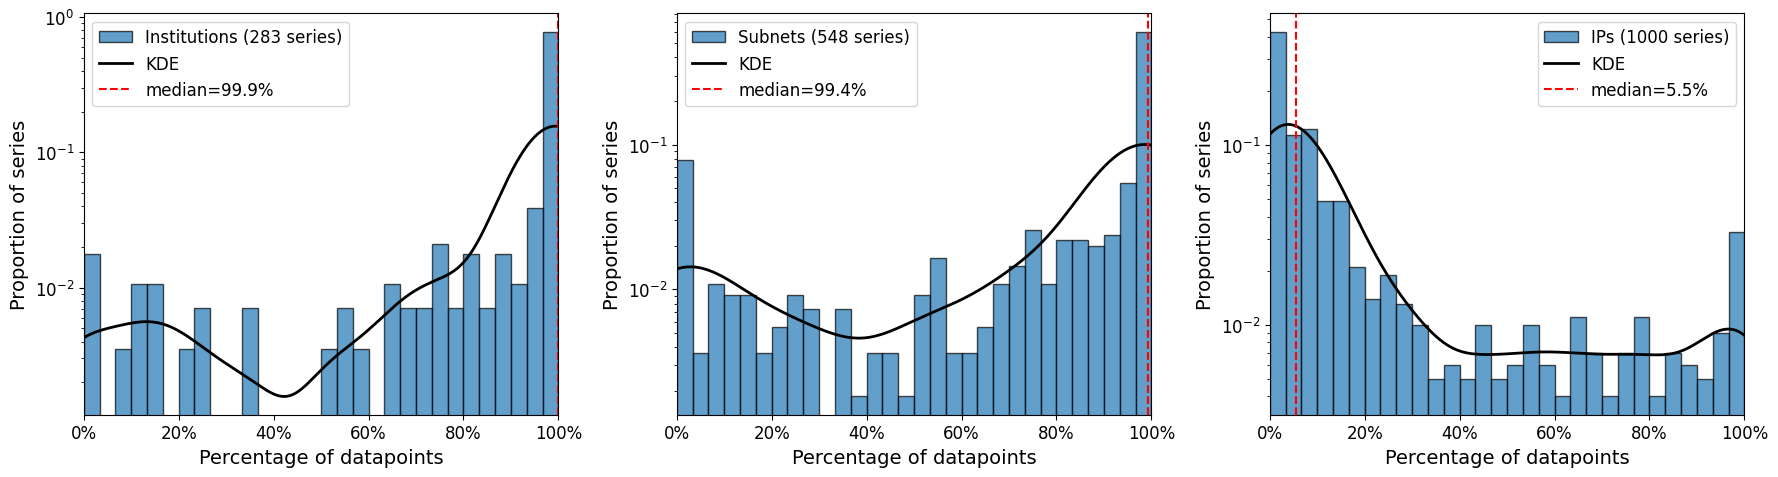

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bins = np.linspace(0, 1, 31)
bin_width = bins[1] - bins[0]
xs = np.linspace(0, 1, 400)

for ax, (df_sp, label) in zip(axes, [
    (sp_inst_10, "Institutions"),
    (sp_sub_10, "Subnets"),
    (sp_ips_10, "IPs"),
]):
    y = df_sp["ratio_active"].values
    weights = np.ones_like(y) / len(y)
    ax.hist(y, bins=bins, weights=weights, edgecolor="black", alpha=0.7,
            label=f"{label} ({len(df_sp)} series)")

    kde = gaussian_kde(y)
    ax.plot(xs, kde(xs) * bin_width, color="black", linewidth=2, label="KDE")

    ax.axvline(np.median(y), color="red", linestyle="--",
               label=f"median={np.median(y)*100:.1f}%")
    ax.set_xlabel("Percentage of datapoints")
    ax.set_ylabel("Proportion of series")
    ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1)
    ax.set_yscale("log")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
    ax.legend()

plt.tight_layout()
plt.show()

/var/folders/xw/ns2nqjw146sg3jt0ghqnyqpw0000gn/T/ipykernel_82143/3425570949.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)


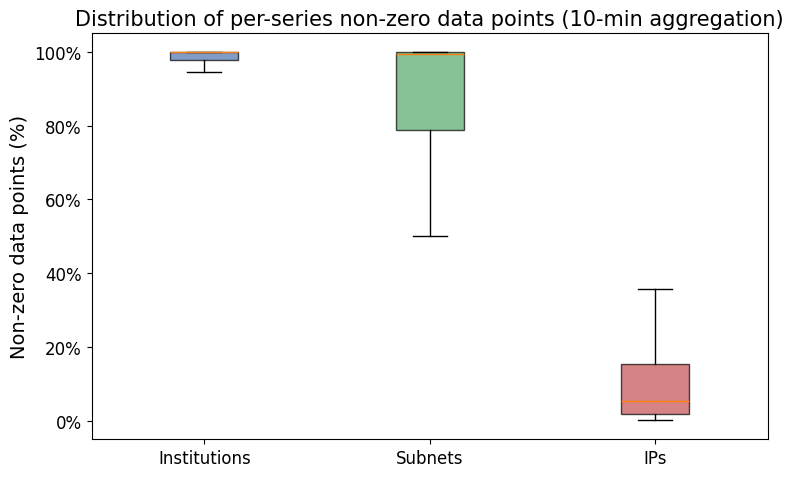

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [sp_inst_10["ratio_active"] * 100, sp_sub_10["ratio_active"] * 100, sp_ips_10["ratio_active"] * 100]
labels = ["Institutions", "Subnets", "IPs"]

bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False)
colors = ["#4C72B0", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel("Non-zero data points (%)")
ax.set_title("Distribution of per-series non-zero data points (10-min aggregation)")
ax.set_ylim(-5, 105)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.tight_layout()
plt.show()

## Sparsity Buckets (10 min)

In [19]:
bins = [0, 0.05, 0.15, 0.30, 0.50, 0.70, 0.85, 0.95, 0.99, 1.001]
labels = ["<5%", "5-15%", "15-30%", "30-50%", "50-70%", "70-85%", "85-95%", "95-99%", ">99%"]

for df_sp, name in [(sp_inst_10, "Institutions"), (sp_sub_10, "Subnets"), (sp_ips_10, "IPs")]:
    df_sp["bucket"] = pd.cut(df_sp["ratio_active"], bins=bins, labels=labels, right=False)
    counts = df_sp["bucket"].value_counts().sort_index()
    print(f"\n=== {name} ===")
    for bucket, count in counts.items():
        pct = count / len(df_sp) * 100
        print(f"  {bucket:>8s}: {count:4d} ({pct:5.1f}%)")


=== Institutions ===
       <5%:    5 (  1.8%)
     5-15%:    4 (  1.4%)
    15-30%:    6 (  2.1%)
    30-50%:    2 (  0.7%)
    50-70%:    9 (  3.2%)
    70-85%:   15 (  5.3%)
    85-95%:   13 (  4.6%)
    95-99%:   28 (  9.9%)
      >99%:  201 ( 71.0%)

=== Subnets ===
       <5%:   44 (  8.0%)
     5-15%:   12 (  2.2%)
    15-30%:   19 (  3.5%)
    30-50%:   10 (  1.8%)
    50-70%:   27 (  4.9%)
    70-85%:   45 (  8.2%)
    85-95%:   43 (  7.8%)
    95-99%:   55 ( 10.0%)
      >99%:  293 ( 53.5%)

=== IPs ===
       <5%:  492 ( 49.2%)
     5-15%:  252 ( 25.2%)
    15-30%:   85 (  8.5%)
    30-50%:   41 (  4.1%)
    50-70%:   44 (  4.4%)
    70-85%:   29 (  2.9%)
    85-95%:   20 (  2.0%)
    95-99%:    9 (  0.9%)
      >99%:   28 (  2.8%)


## Most Sparse and Most Dense Series (10 min)

In [20]:
for df_sp, label, id_col in [
    (sp_inst_10, "Institutions", "id_institution"),
    (sp_sub_10, "Subnets", "id_institution_subnet"),
    (sp_ips_10, "IPs", "id_ip"),
]:
    print(f"\n=== {label} — Most Sparse (lowest activity) ===")
    display(df_sp.sort_values("ratio_active").head(10)[[id_col, "ratio_active", "n_active", "n_zero"]])
    
    print(f"\n=== {label} — Most Dense (highest activity) ===")
    display(df_sp.sort_values("ratio_active", ascending=False).head(10)[[id_col, "ratio_active", "n_active", "n_zero"]])


=== Institutions — Most Sparse (lowest activity) ===


,id_institution,ratio_active,n_active,n_zero
265,267.0,0.000000,0,40298
258,260.0,0.000000,0,40298
277,279.0,0.000000,0,40298
147,148.0,0.000000,0,40298
281,283.0,0.000000,0,40298
150,151.0,0.084421,3402,36896
278,280.0,0.122016,4917,35381
262,264.0,0.122810,4949,35349
280,282.0,0.127178,5125,35173
245,247.0,0.151968,6124,34174



=== Institutions — Most Dense (highest activity) ===


,id_institution,ratio_active,n_active,n_zero
0,0.0,1.0,40298,0
82,83.0,1.0,40298,0
80,81.0,1.0,40298,0
79,80.0,1.0,40298,0
77,78.0,1.0,40298,0
74,75.0,1.0,40298,0
194,196.0,1.0,40298,0
68,69.0,1.0,40298,0
67,68.0,1.0,40298,0
66,67.0,1.0,40298,0



=== Subnets — Most Sparse (lowest activity) ===


...

,id_institution_subnet,ratio_active,n_active,n_zero
141,141.0,1.0,40298,0
362,362.0,1.0,40298,0
238,238.0,1.0,40298,0
322,322.0,1.0,40298,0
136,136.0,1.0,40298,0
324,324.0,1.0,40298,0
342,342.0,1.0,40298,0
345,345.0,1.0,40298,0
211,211.0,1.0,40298,0
58,58.0,1.0,40298,0



=== IPs — Most Sparse (lowest activity) ===


,id_ip,ratio_active,n_active,n_zero
646,1502881.0,0.002630,106,40192
632,849787.0,0.002879,116,40182
676,1548362.0,0.003152,127,40171
683,1553020.0,0.003176,128,40170
552,724720.0,0.003201,129,40169
678,1550502.0,0.003276,132,40166
747,1625739.0,0.003350,135,40163
393,477964.0,0.003375,136,40162
655,1513927.0,0.003375,136,40162
787,1698357.0,0.003400,137,40161



=== IPs — Most Dense (highest activity) ===


,id_ip,ratio_active,n_active,n_zero
0,11.0,1.000000,40298,0
43,10256.0,1.000000,40298,0
15,1367.0,0.999975,40297,1
3,103.0,0.999950,40296,2
17,1370.0,0.999876,40293,5
16,1368.0,0.999801,40290,8
50,11069.0,0.999777,40289,9
137,109544.0,0.999454,40276,22
45,10396.0,0.999429,40275,23
6,122.0,0.999380,40273,25
